# <center> Statistics using R

#### Loading the dependencies

In [2]:
library(tidyverse, warn.conflicts = F)
library(modeest, warn.conflicts = F)
library(moments, warn.conflicts = F)
library(broom, warn.conflicts = F)

#### About the dataset we are using
The Iris dataset is essentially the "Hello World" of the data science world. Introduced by the British statistician and biologist Ronald Fisher in 1936, it remains the gold standard for practicing classification and clustering algorithms.
- Dataset Composition
The dataset consists of 150 samples from three different species of the Iris flower. For each sample, four specific physical features were measured (in centimeters):

1. Sepal Length

2. Sepal Width

3. Petal Length

4. Petal Width

- The Three Species
The data is balanced, containing exactly 50 samples per species:

1. Iris Setosa: Easily identifiable because its petals are much smaller and its features are distinctly clustered away from the other two.

2. Iris Versicolor: The "middle ground" species; its measurements often overlap slightly with Virginica.

3. Iris Virginica: Generally has the largest petals and sepals.

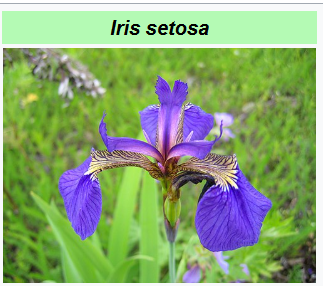
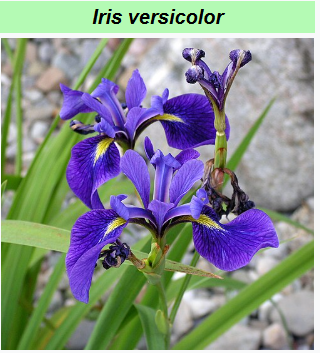
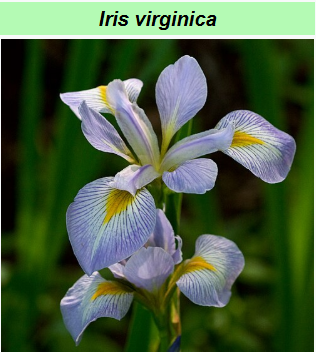

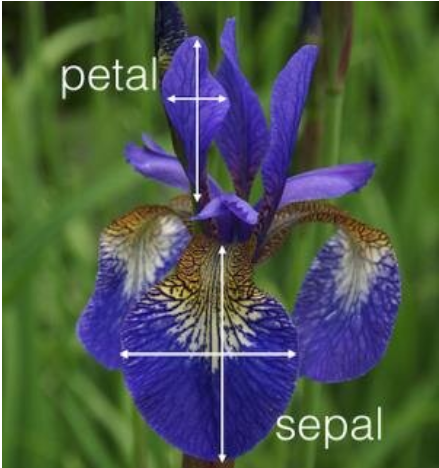

#### Loading the dataset

In [3]:
data <- read.csv('./iris.csv')

#### Converting into tibble

In [4]:
data <- as_tibble(data)

#### Inspecting the tibble

In [5]:
head(data, 10)

sepal_length,sepal_width,petal_length,petal_width,species
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa


In [6]:
tail(data, 10)

sepal_length,sepal_width,petal_length,petal_width,species
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6.7,3.1,5.6,2.4,virginica
6.9,3.1,5.1,2.3,virginica
5.8,2.7,5.1,1.9,virginica
6.8,3.2,5.9,2.3,virginica
6.7,3.3,5.7,2.5,virginica
6.7,3.0,5.2,2.3,virginica
6.3,2.5,5.0,1.9,virginica
6.5,3.0,5.2,2.0,virginica
6.2,3.4,5.4,2.3,virginica


In [7]:
sample_n(data, 10)

sepal_length,sepal_width,petal_length,petal_width,species
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7.9,3.8,6.4,2.0,virginica
5.1,3.8,1.5,0.3,setosa
5.1,3.8,1.6,0.2,setosa
5.7,4.4,1.5,0.4,setosa
6.4,3.2,5.3,2.3,virginica
7.2,3.2,6.0,1.8,virginica
4.7,3.2,1.3,0.2,setosa
7.7,2.6,6.9,2.3,virginica
6.0,2.9,4.5,1.5,versicolor


#### Checking the dimensions

In [8]:
dim(data)

[1] 150   5

#### Checking the structure

In [9]:
str(data)

tibble [150 × 5] (S3: tbl_df/tbl/data.frame)
 $ sepal_length: num [1:150] 5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ sepal_width : num [1:150] 3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ petal_length: num [1:150] 1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ petal_width : num [1:150] 0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ species     : chr [1:150] "setosa" "setosa" "setosa" "setosa" ...


#### <center> Levels of Statistics in Data analytics

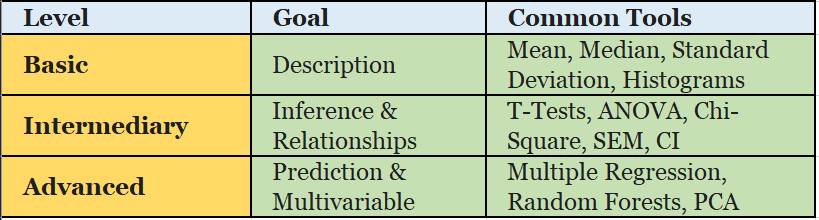

#### Basics statistics
- These include mean, median mode and correlation coefficients
- Lets use the column "petal_length" for the demonstration

##### Mean

In [10]:
data$sepal_length %>% mean()

[1] 5.843333

##### Median

In [11]:
data$sepal_length %>% median()

[1] 5.8

##### Mode
The modeest (Mode Estimation) package is dedicated entirely to finding the mode. Its main function is mlv() which stands for "Most Likely Value." It is highly advanced and can estimate the mode for continuous distributions, not just discrete integers.

In [12]:
data %>% mlv(x = data$sepal_length, method = "mfv")

[1] 5

#### Intermediate Staistics
In data analytics, intermediary statistics (often referred to as Intermediate Statistics) represents the bridge between basic descriptive summaries and advanced predictive modeling or machine learning.

While "Basic Stats" tells you what happened (mean, median, mode), "Intermediary Stats" focuses on Inference: determining if the patterns you see are "real" or just the result of random noise.
#### Key Components of Intermediary Statistics
1. Inferential Hypothesis TestingThis is the core of intermediary stats. It involves using samples to make "educated guesses" about a whole population.
- Concepts: Null and Alternative Hypotheses, P-values, and Type I/Type II errors.
- Goal: To decide if a change (like a new website UI) actually caused a change in behavior.
2. Analysis of Variance (ANOVA)While basic stats compares two groups, intermediary stats introduces ANOVA to compare three or more groups simultaneously.
- Use Case: Comparing the average spending of customers across four different regions to see if location truly impacts revenue.
3. Correlation and Simple Linear RegressionThis moves beyond just looking at one variable to looking at the relationship between two variables.
- Correlation: How strongly are they related? (e.g., does advertising spend correlate with sales?)
- Regression: Can we predict one based on the other? ($y = mx + b$)
4. Non-Parametric Tests : Basic statistics often assumes your data follows a "Normal" (bell-shaped) curve. Intermediary statistics teaches you what to do when your data is "messy" or skewed, using tests like the Mann-Whitney U or Kruskal-Wallis.

#### Sub setting the data based on the species

##### Getting the unique species

In [13]:
unique(data$species)

[1] "setosa"     "versicolor" "virginica"

In [14]:
data_setosa = data %>% subset(species == "setosa")
data_versicolor = data %>%subset(species == 'versicolor')
data_virginica = data %>% subset(species == 'virginica')

In [15]:
head(data_setosa)

sepal_length,sepal_width,petal_length,petal_width,species
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa


In [16]:
head(data_versicolor)

sepal_length,sepal_width,petal_length,petal_width,species
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7.0,3.2,4.7,1.4,versicolor
6.4,3.2,4.5,1.5,versicolor
6.9,3.1,4.9,1.5,versicolor
5.5,2.3,4.0,1.3,versicolor
6.5,2.8,4.6,1.5,versicolor
5.7,2.8,4.5,1.3,versicolor


In [17]:
head(data_virginica)

sepal_length,sepal_width,petal_length,petal_width,species
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6.3,3.3,6.0,2.5,virginica
5.8,2.7,5.1,1.9,virginica
7.1,3.0,5.9,2.1,virginica
6.3,2.9,5.6,1.8,virginica
6.5,3.0,5.8,2.2,virginica
7.6,3.0,6.6,2.1,virginica


### Graphical method to check the distribution

#### Histograms

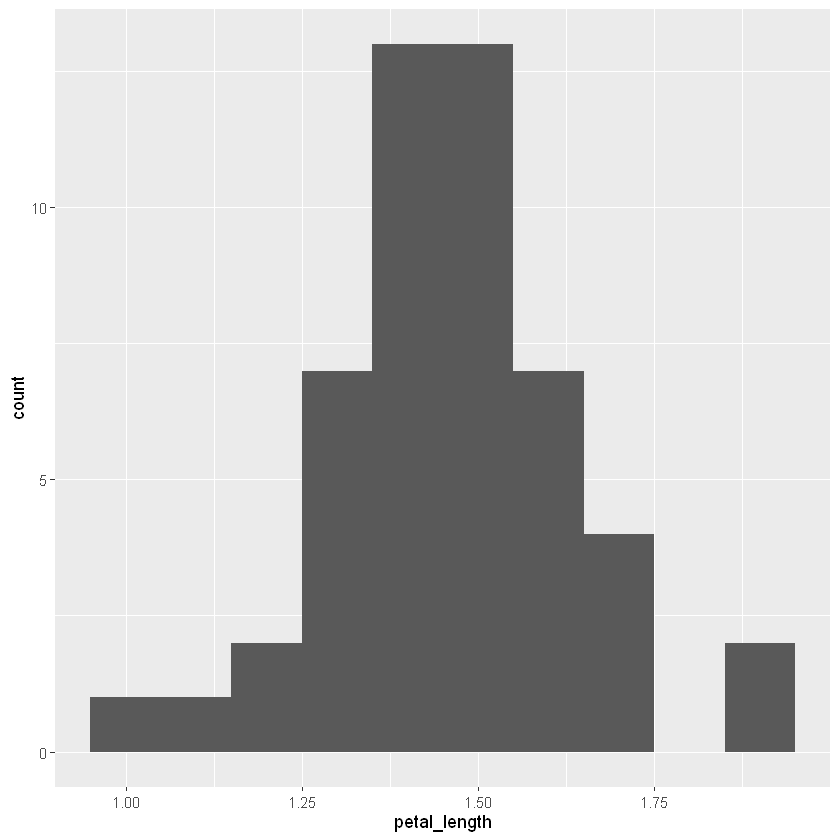

In [18]:
ggplot(data = data_setosa,
      mapping = aes(x = petal_length))+geom_histogram(bins = 10)

#### Density plot

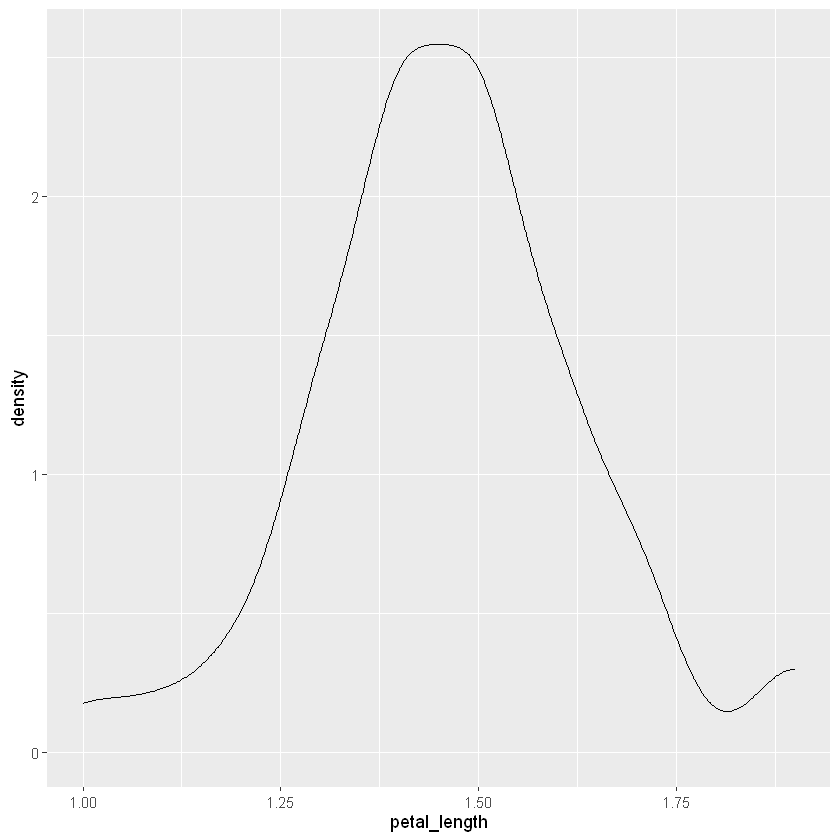

In [19]:
ggplot(data = data_setosa,
      mapping = aes(x = petal_length))+geom_density()

#### Skewness

In [20]:
skewness(x = data_setosa$petal_length)

[1] 0.1031751

#### Kurtosis

In [21]:
kurtosis(x = data$petal_length)

[1] 1.604464

#### Statistical tests

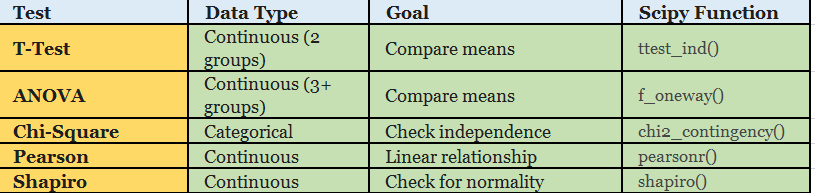

#### Normality Test (Shapiro-Wilk)
- Purpose: Most of the tests above (T-test, ANOVA) assume your data follows a Normal Distribution. You use this test to check that assumption.
- Hypothesis: $H_0$: The data is normally distributed.

In [22]:
shapiro.test(data_setosa$petal_length)


	Shapiro-Wilk normality test

data:  data_setosa$petal_length
W = 0.95498, p-value = 0.05481


#### T-Test (Independent Samples)
- Purpose: To determine if the means of two independent groups are significantly different.
- Hypothesis: $H_0$ (Null): The means are equal. $H_a$ (Alt): The means are different.
- Example: Is there a significant difference in petal length between Setosa and Versicolor?

In [23]:
ttest_result <- t.test(data_setosa$petal_length, data_versicolor$petal_length)
ttest_result


	Welch Two Sample t-test

data:  data_setosa$petal_length and data_versicolor$petal_length
t = -39.493, df = 62.14, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -2.939618 -2.656382
sample estimates:
mean of x mean of y 
    1.462     4.260 


- We reject the null hypothesis, meaning the difference is "statistically significant."

#### ANOVA (Analysis of Variance)
- Purpose: An extension of the t-test used when you have three or more groups. It tells you if at least one group mean is different from the others.
- Hypothesis: $H_0$: All group means are equal.
- Example: Does petal length vary across all three species?

In [24]:
ANOVA_result <- aov(petal_length ~ species, data = data)
ANOVA_result

Call:
   aov(formula = petal_length ~ species, data = data)

Terms:
                 species Residuals
Sum of Squares  437.1028   27.2226
Deg. of Freedom        2       147

Residual standard error: 0.4303345
Estimated effects may be unbalanced

- To see the p-value and the F-statistic, you must wrap your result in the summary() function.

In [25]:
summary(ANOVA_result)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  437.1  218.55    1180 <2e-16 ***
Residuals   147   27.2    0.19                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

- The column : Pr(>F) is your p-value.

#### Chi-Square Test ($\chi^2$)Purpose: Used for categorical data to see if two variables are independent.
- Hypothesis: $H_0$: The variables are independent (no relationship).
- Example: Since Iris is mostly numeric, we’ll create a dummy category: "Large" vs "Small" petals, and see if that category is independent of the Species.
- We have to preparet the data first by crating a column showing the categories - Small and Large
- Then we needd to create the cross tablulation between Species and Category.

#### Find the median of petal length

In [26]:
median_petal_length <- median(data$petal_length)
median_petal_length

[1] 4.35

In [27]:
data$category <- ifelse(data$petal_length > median_petal_length, "Large", "Small")

In [28]:
sample_n(data, 10)

sepal_length,sepal_width,petal_length,petal_width,species,category
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
4.9,2.4,3.3,1.0,versicolor,Small
5.4,3.4,1.7,0.2,setosa,Small
7.7,3.0,6.1,2.3,virginica,Large
5.7,3.0,4.2,1.2,versicolor,Small
7.7,3.8,6.7,2.2,virginica,Large
7.7,2.6,6.9,2.3,virginica,Large
4.3,3.0,1.1,0.1,setosa,Small
6.3,3.4,5.6,2.4,virginica,Large
6.1,3.0,4.6,1.4,versicolor,Large


#### Count Plot

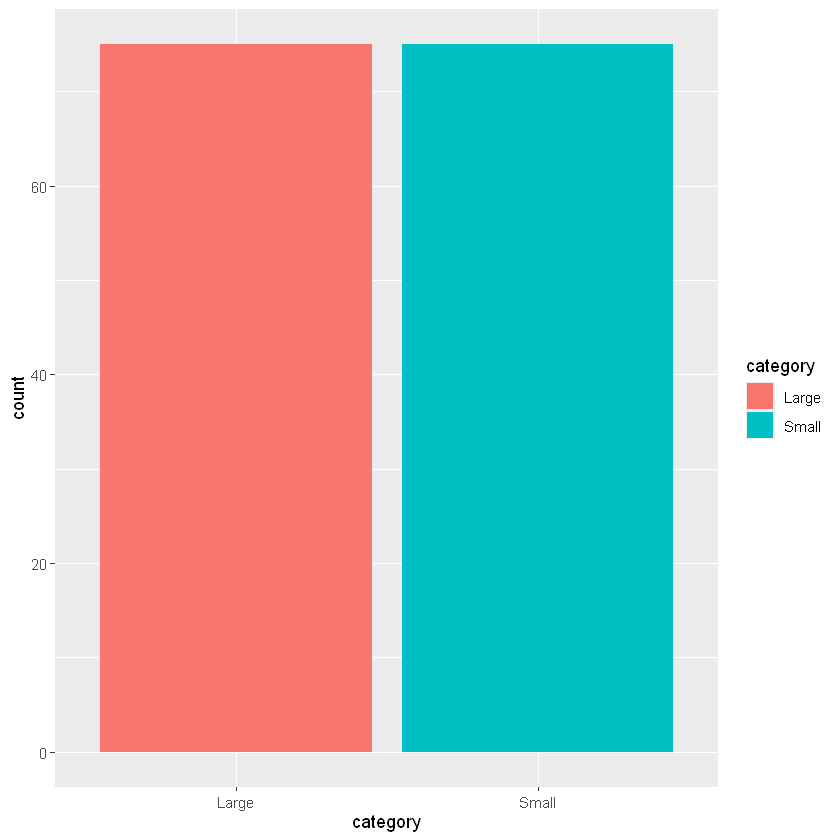

In [29]:
ggplot(data = data,
      mapping = aes(x = category, fill = category))+geom_bar()

#### Contigency table

In [30]:
crosstab <- table(data$species, data$category)
crosstab

            
             Large Small
  setosa         0    50
  versicolor    25    25
  virginica     50     0

In [31]:
chi_square_result <- chisq.test(crosstab)
chi_square_result


	Pearson's Chi-squared test

data:  crosstab
X-squared = 100, df = 2, p-value < 2.2e-16


#### Correlation (Pearson’s r)
- Purpose: To measure the linear relationship between two continuous variables.
- Range: -1 (perfect negative) to +1 (perfect positive).
- Hypothesis ($H_0$): There is no linear correlation between the two variables.
- Example: Does sepal length correlate with petal length?

In [32]:
cor(x = data$petal_length, y = data$sepal_width, method = "pearson")

[1] -0.4284401

#### Confidence Interval (CI) for the mean
- A Confidence Interval (CI) for the mean is a range of values that is likely to contain the true population mean based on a sample of data. It represents the degree of uncertainty around a sample estimate.
- For example, a 95% confidence interval means that if you were to repeat the experiment 100 times, the calculated interval would contain the true population mean in approximately 95 of those instances.

In [33]:
data %>%
  pull(petal_length) %>%
  t.test() %>%
  tidy() %>%
  select(conf.low, conf.high)

conf.low,conf.high
<dbl>,<dbl>
3.473185,4.042815


- The above 2 values show the Lower and Upper CI's

#### Standard Error of the Mean (SEM)
- The Standard Error of the Mean (SEM) measures how far the sample mean of your data is likely to be from the true population mean.

- While the Standard Deviation (SD) tells you how much individual data points spread out from the mean, the Standard Error tells you how much the average itself would fluctuate if you took multiple different samples from the same population.

- The SEM is calculated by taking the Standard Deviation ($s$) and dividing it by the square root of the sample size ($n$):$$SEM = \frac{s}{\sqrt{n}}$$

- SEM focuses on how "precise" the mean estimate is.

- Decreases as $n$ increases (the mean becomes more certain).

In [34]:
data %>%
  summarize(
    mean_petal_length = mean(petal_length),
    sd_petal_length = sd(petal_length),
    n = n(),
    sem_petal_length = sd_petal_length / sqrt(n)
  )

mean_petal_length,sd_petal_length,n,sem_petal_length
<dbl>,<dbl>,<int>,<dbl>
3.758,1.765298,150,0.144136
